# Machine Learning for Chemistry (CH 610) - Project
## Abstract

Hantavirus represents a significant zoonotic threat, which the 2026 cruise ship outbreak has clearly indicated to the general public. The virus causes two severe clinical syndromes, Hantavirus Pulmonary Syndrome (HPS) and Hemorrhagic Fever with Renal Syndrome (HFRS), with case fatality rates that can exceed 30-40% in some regions. Systematic surveillance and early disease classification are increasingly critical for effective public health response. This study leverages a clinical dataset of 7,500 hantavirus cases across 30 years of outbreaks to classify case outcome, severity, and syndrome based on incubation period, ICU admission, hospital stay length, and symptoms.

### Setup

In [ ]:
import kagglehub

# Download latest version of hantavirus dataset

# path = kagglehub.dataset_download("zkskhurram/hantavirus-andes-virus-global-epidemiology")
# print("Path to dataset files:", path)

Path to dataset files: C:\Users\alexa\.cache\kagglehub\datasets\zkskhurram\hantavirus-andes-virus-global-epidemiology\versions\5


In [ ]:
import sys
assert sys.version_info >= (3, 7)
from packaging import version
import sklearn
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer # Convert symptom and demographic data without having to split and recombine
import warnings
warnings.filterwarnings("ignore")

In [921]:
df = pd.read_csv('hantavirus_clinical.csv').fillna(0)
HPS = df[df["syndrome"]=="HPS"]
HFRS = df[df["syndrome"]=='HFRS']

print(f"Total cases: {len(df)}\nHPS patients: {len(HPS)}\nHFRS patients: {len(HFRS)}")

Total cases: 7538
HPS patients: 2620
HFRS patients: 4918


# A: Outcome classification

Features: hospital_days, icu_admission, icu_days, virus_strain, age_group, gender

Target: outcome (Recovered/Deceased)

In [902]:
# Import packages
from sklearn.model_selection import StratifiedKFold, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (RocCurveDisplay, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay, 
                             precision_recall_fscore_support
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings("ignore")

In [903]:
# Set up preprocessor to handle encoding and scaling of demographic and numeric data
def preprocessor(cat_cols, num_cols):
    return ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("num", StandardScaler(), num_cols),
    ])

In [904]:
Dem = ["virus_strain", "age_group", "gender"]
Num = ["hospital_days", "icu_admission", "icu_days", "incubation_days"]
 
Xa = df[Dem + Num]
ya = (df["outcome"] == "Deceased").astype(int)

Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    Xa, ya, test_size=0.2, random_state=42, stratify=ya)

In [905]:
outcome_models = {
    "Logistic Regression": Pipeline([
        ("pre", preprocessor(Dem, Num)),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("pre", preprocessor(Dem, Num)),
        ("clf", RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                       random_state=42, n_jobs=-1))
    ]),
    "Gradient Boosting": Pipeline([
        ("pre", preprocessor(Dem, Num)),
        ("clf", GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                           max_depth=4, random_state=42))
    ]),
}

In [910]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_a = {}
fitted_a  = {}
 
for name, pipe in outcome_models.items():
    cv_auc = cross_val_score(pipe, Xa_train, ya_train, cv=cv,
                             scoring="roc_auc", n_jobs=-1) # Using area under the curve score
    pipe.fit(Xa_train, ya_train)
    ya_pred  = pipe.predict(Xa_test)
    ya_prob = pipe.predict_proba(Xa_test)[:, 1]
    test_auc = roc_auc_score(ya_test, ya_prob)
    results_a[name] = {"cv_auc": cv_auc.mean(), "cv_std": cv_auc.std(),
                       "test_auc": test_auc}
    fitted_a[name]  = (pipe, ya_pred, ya_prob)
    print(f"{name} - CV AUC: {cv_auc.mean():.3f} ± {cv_auc.std():.3f} | Test AUC: {test_auc:.3f}")
    precision, recall, f1, support = precision_recall_fscore_support(ya_test, ya_pred, beta=1.0)
    print(f"  Precision = {precision}\n  Recall =  {recall}\n  F1 score = {f1}")

Logistic Regression - CV AUC: 0.882 ± 0.009 | Test AUC: 0.880
  Precision = [0.95678479 0.4045584 ]
  Recall =  [0.84118541 0.73958333]
  F1 score = [0.8952689  0.52302026]
Random Forest - CV AUC: 0.851 ± 0.008 | Test AUC: 0.842
  Precision = [0.91201717 0.62727273]
  Recall =  [0.96884498 0.359375  ]
  F1 score = [0.93957259 0.45695364]
Gradient Boosting - CV AUC: 0.877 ± 0.011 | Test AUC: 0.881
  Precision = [0.90845563 0.79220779]
  Recall =  [0.98784195 0.31770833]
  F1 score = [0.94648708 0.4535316 ]


In [912]:
rf_a_pipe = fitted_a["Random Forest"][0]
feat_names_a = [f.split("__", 1)[-1] 
              for f in rf_a_pipe.named_steps["pre"].get_feature_names_out()]
feat_names_a = [v.replace('_', ' ') if isinstance(v, str) else v for v in feat_names_a]
importances = rf_a_pipe.named_steps["clf"].feature_importances_
imp_df_a = (pd.DataFrame({"feature": feat_names_a, "importance": importances})
          .sort_values("importance", ascending=False).head(12))


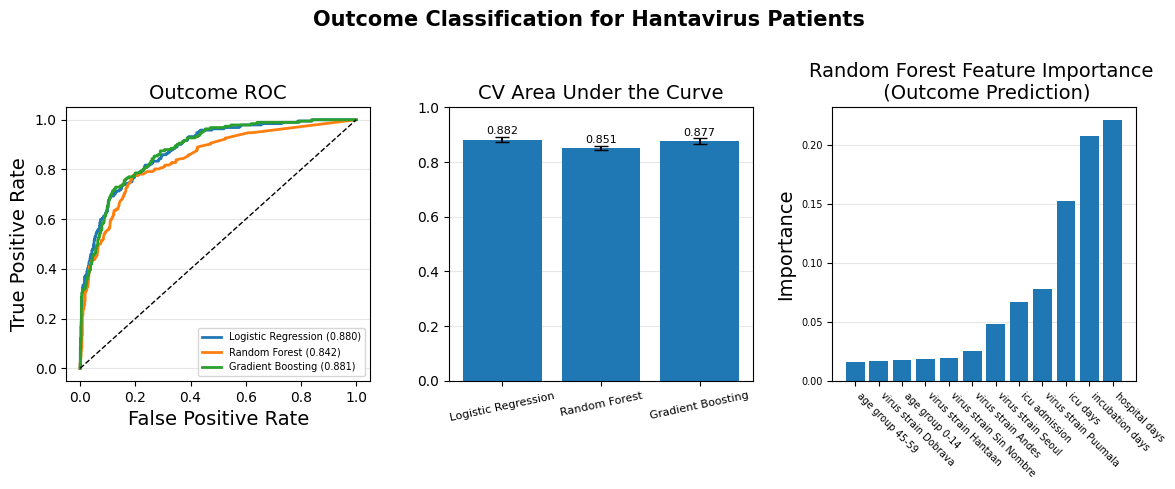

In [913]:
fig, axes = plt.subplots(1,3, figsize=(12,5))
fig.suptitle("Outcome Classification for Hantavirus Patients", fontsize=15, fontweight="bold")
for ax in axes: ax.set_axisbelow(True)

# ROC curve for each model
for name, (_, _, yp) in fitted_a.items():
    fpr, tpr, _ = roc_curve(ya_test, yp)
    axes[0].plot(fpr, tpr, label=f"{name} ({results_a[name]['test_auc']:.3f})", lw=2)
axes[0].plot([0,1],[0,1],"k--",lw=1)
axes[0].set(title="Outcome ROC", xlabel="False Positive Rate", ylabel="True Positive Rate")
axes[0].legend(fontsize=7, loc="lower right")
axes[0].grid(axis="y", alpha=0.3)

# Cross-validated Area Under the Curve for each model
ns = list(results_a.keys())
axes[1].bar(ns, [results_a[n]["cv_auc"] for n in ns],
            yerr=[results_a[n]["cv_std"] for n in ns],
            capsize=5)
axes[1].set_ylim(0, 1.0)
axes[1].set_title("CV Area Under the Curve")
axes[1].set_xticklabels(ns, rotation=12, ha="center", fontsize=8)
for i, n in enumerate(ns):
    axes[1].text(i, results_a[n]["cv_auc"] + 0.02,
                 f"{results_a[n]['cv_auc']:.3f}", ha="center", fontsize=8)
axes[1].grid(axis="y", alpha=0.3)

# plot 3: feature importance for random forest classification 
axes[2].bar(imp_df_a["feature"][::-1], imp_df_a["importance"][::-1])
axes[2].set_title("Random Forest Feature Importance \n (Outcome Prediction)")
axes[2].set_ylabel("Importance")
axes[2].tick_params(labelsize=7)
axes[2].set_xticks(axes[2].get_xticks(), axes[2].get_xticklabels(), rotation=-45, ha='left')
axes[2].grid(axis="y", alpha=0.3)
plt.tight_layout()

Patient outcome is closely linked to length of hospital stay and time in intensive care

----

# B: Severity Classification
Features: hospital_days, icu_admission, icu_days, virus_strain, age_group, gender

Target: severity (Mild / Moderate / Severe / Critical)

In [688]:
Xb = df[Dem + Num]
yb = df["severity"]
 
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb, yb, test_size=0.2, random_state=42, stratify=yb)

In [689]:
severity_models = {
    "Logistic Regression": Pipeline([
        ("pre", preprocessor(Dem, Num)),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced",
                                   random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("pre", preprocessor(Dem, Num)),
        ("clf", RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                       random_state=42, n_jobs=-1))
    ]),
    "Gradient Boosting": Pipeline([
        ("pre", preprocessor(Dem, Num)),
        ("clf", GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                           max_depth=4, random_state=42))
    ]),
}
results_b = {}
fitted_b  = {}


In [914]:
for name, pipe in severity_models.items():
    cv_acc = cross_val_score(pipe, Xb_train, yb_train, cv=cv,
                             scoring="accuracy", n_jobs=-1)
    pipe.fit(Xb_train, yb_train)
    yb_pred = pipe.predict(Xb_test)
    results_b[name] = {"cv_acc": cv_acc.mean(), "cv_std": cv_acc.std()}
    fitted_b[name]  = (pipe, yb_pred)
    print(f"\n{name} — CV Acc: {cv_acc.mean():.3f} ± {cv_acc.std():.3f}")
    precision, recall, f1, support = precision_recall_fscore_support(yb_test, yb_pred, beta=1.0)
    print(f"  Precision = {precision}\n  Recall =  {recall}\n  F1 score = {f1}")


Logistic Regression — CV Acc: 0.994 ± 0.002
  Precision = [1.         0.94915254 1.         1.        ]
  Recall =  [1.         1.         0.97752809 1.        ]
  F1 score = [1.         0.97391304 0.98863636 1.        ]

Random Forest — CV Acc: 1.000 ± 0.000
  Precision = [1. 1. 1. 1.]
  Recall =  [1. 1. 1. 1.]
  F1 score = [1. 1. 1. 1.]

Gradient Boosting — CV Acc: 1.000 ± 0.000
  Precision = [1. 1. 1. 1.]
  Recall =  [1. 1. 1. 1.]
  F1 score = [1. 1. 1. 1.]


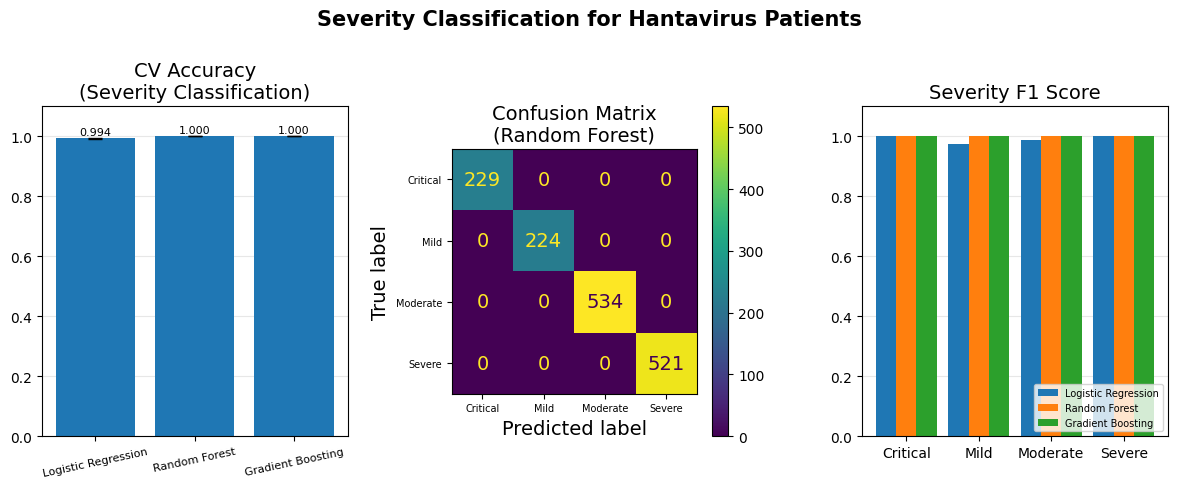

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(12,5))
fig.suptitle("Severity Classification for Hantavirus Patients", fontsize=15, fontweight="bold")
for ax in axes: ax.set_axisbelow(True)

# CV
ns_b = list(results_b.keys())
axes[0].bar(ns_b, [results_b[n]["cv_acc"] for n in ns_b],
            yerr=[results_b[n]["cv_std"] for n in ns_b],
            capsize=5)
axes[0].set_ylim(0, 1.1)
axes[0].set_title("CV Accuracy\n(Severity Classification)")
axes[0].set_xticklabels(ns_b, rotation=12, ha="center", fontsize=8)
axes[0].grid(axis="y", alpha=0.3)
for i, n in enumerate(ns_b):
    axes[0].text(i, results_b[n]["cv_acc"] + 0.01,
                 f"{results_b[n]['cv_acc']:.3f}", ha="center", fontsize=8)
 

# Confusion Matrix for best-performing model (Random forest)
best_b = max(results_b, key=lambda n: results_b[n]["cv_acc"])
ConfusionMatrixDisplay.from_predictions(
    yb_test, fitted_b[best_b][1],
    display_labels=["Critical","Mild","Moderate","Severe"], ax=axes[1],
)
axes[1].set_title(f"Confusion Matrix\n({best_b})")
axes[1].tick_params(labelsize=7)
 

# F1 bar chart for each Severity
from sklearn.metrics import f1_score
classes = ["Critical", "Mild", "Moderate", "Severe"]
width = 0.28
x = np.arange(len(classes))
axes[2].set_axisbelow(True)
for i, (name, (_, yb_pred)) in enumerate(fitted_b.items()):
    f1s = f1_score(yb_test, yb_pred, labels=classes, average=None)
    axes[2].bar(x + i*width, f1s, width, label=name)
axes[2].set_xticks(x + width)
axes[2].set_xticklabels(classes)
axes[2].set_ylim(0, 1.1)
axes[2].set_title("Severity F1 Score")
axes[2].legend(loc="lower right", fontsize=7)
axes[2].grid(axis="y", alpha=0.3)
plt.tight_layout()

Case severity is significantly linked to length of hospital stay and time in intensive care

---

# C: Syndrome Classification 

Features: Symptoms (17 booleans)

Target: Syndrome

In [ ]:
Symp = [ # Boolean values for presence/absence of symptoms in HPS patient
    "fever", "myalgia", "headache", "cough", "dyspnea", "nausea", "tachycardia", 
    "hypotension", "pulmonary_edema", "thrombocytopenia","back_pain", "abdominal_pain", 
    "blurred_vision", "petechiae", "oliguria", "proteinuria", "hemorrhage"
]

Xc = df[Symp]
yc = (df["syndrome"] == "HPS").astype(int) # Prediction target

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.2, random_state=42, stratify=yc)

In [667]:
syndrome_models = {
    "Logistic Regression": Pipeline([
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
    ]),
    "Random Forest": Pipeline([
        
        ("clf", RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                       random_state=42, n_jobs=-1))
    ]),
    "Gradient Boosting": Pipeline([
        
        ("clf", GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                           max_depth=4, random_state=42))
    ]),
}

In [915]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_c = {}
fitted_c  = {}

for name, pipe in syndrome_models.items():
    cv_auc = cross_val_score(pipe, Xc_train, yc_train, cv=cv,
                             scoring="roc_auc", n_jobs=-1) # Using area under the curve score
    pipe.fit(Xc_train, yc_train)
    yc_pred  = pipe.predict(Xc_test)
    yc_prob = pipe.predict_proba(Xc_test)[:, 1]
    test_auc = roc_auc_score(yc_test, yc_prob)
    results_c[name] = {"cv_auc": cv_auc.mean(), "cv_std": cv_auc.std(),
                       "test_auc": test_auc}
    fitted_c[name]  = (pipe, yc_pred, yc_prob)
    print(f"{name} - CV AUC: {cv_auc.mean():.3f} ± {cv_auc.std():.3f} | Test AUC: {test_auc:.3f}")
    precision, recall, f1, support = precision_recall_fscore_support(yc_test, yc_pred, beta=1.0)
    print(f"  Precision = {precision}\n  Recall =  {recall}\n  F1 score = {f1}")

Logistic Regression - CV AUC: 1.000 ± 0.000 | Test AUC: 1.000
  Precision = [1. 1.]
  Recall =  [1. 1.]
  F1 score = [1. 1.]
Random Forest - CV AUC: 1.000 ± 0.000 | Test AUC: 1.000
  Precision = [1. 1.]
  Recall =  [1. 1.]
  F1 score = [1. 1.]
Gradient Boosting - CV AUC: 1.000 ± 0.000 | Test AUC: 1.000
  Precision = [1. 1.]
  Recall =  [1. 1.]
  F1 score = [1. 1.]


In [918]:
rf_c_pipe = fitted_c["Random Forest"][0]
feat_names_c = [v.replace('_', ' ') if isinstance(v, str) else v for v in Symp]
importances = rf_c_pipe.named_steps["clf"].feature_importances_
imp_df_c = (pd.DataFrame({"feature": feat_names_c, "importance": importances})
          .sort_values("importance", ascending=False).head(17))

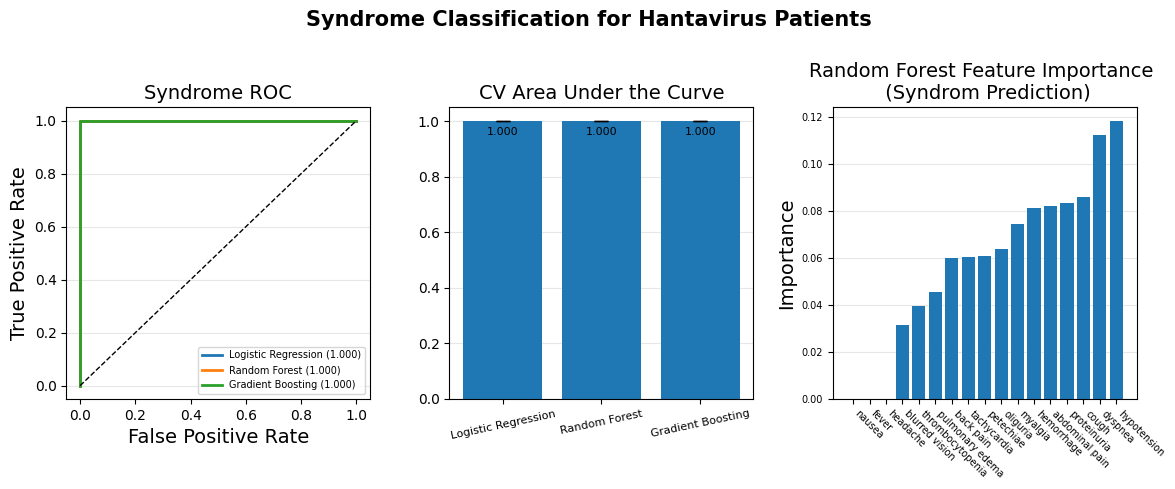

In [919]:
fig, axes = plt.subplots(1,3, figsize=(12,5))
fig.suptitle("Syndrome Classification for Hantavirus Patients", fontsize=15, fontweight="bold")
for ax in axes: ax.set_axisbelow(True)

# ROC curve for each model
for name, (_, _, yp) in fitted_c.items():
    fpr, tpr, _ = roc_curve(yc_test, yp)
    axes[0].plot(fpr, tpr, label=f"{name} ({results_c[name]['test_auc']:.3f})",
                lw=2)
axes[0].plot([0,1],[0,1],"k--",lw=1)
axes[0].set(title="Syndrome ROC", xlabel="False Positive Rate", ylabel="True Positive Rate")
axes[0].legend(fontsize=7, loc="lower right")
axes[0].grid(axis="y", alpha=0.3)

# Cross-validated Area Under the Curve for each model
ns = list(results_c.keys())
axes[1].bar(ns, [results_c[n]["cv_auc"] for n in ns],
            yerr=[results_c[n]["cv_std"] for n in ns],
            capsize=5)
axes[1].set_ylim(0, 1.05)
axes[1].set_title("CV Area Under the Curve")
axes[1].set_xticklabels(ns, rotation=12, ha="center", fontsize=8)
for i, n in enumerate(ns):
    axes[1].text(i, results_c[n]["cv_auc"] - 0.05,
                 f"{results_c[n]['cv_auc']:.3f}", ha="center", fontsize=8)
axes[1].grid(axis="y", alpha=0.3)

# plot 3: feature importance for random forest classification 
axes[2].bar(imp_df_c["feature"][::-1], imp_df_c["importance"][::-1])
axes[2].set_title("Random Forest Feature Importance \n (Syndrom Prediction)")
axes[2].set_ylabel("Importance")
axes[2].tick_params(labelsize=7)
axes[2].set_xticks(axes[2].get_xticks(), 
                   axes[2].get_xticklabels(), rotation=-45, ha='left')
axes[2].grid(axis="y", alpha=0.3)
plt.tight_layout()

Because 14/17 symptoms are exclusive to HPS or HFRS in this dataset, these results likely do not reflect the clinical reality that symptoms may overlap between syndromes

---

# D: Temporal Mortality Regression 
Split by syndrome

Features: year, who_region, latitude, longitude, confirmed_cases, hospitalized, icu_admissions, human_to_human_cases, cfr_lag1, cfr_lag3

Target: case_fatality_rate

In [748]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [864]:
dfy = pd.read_csv('hantavirus_country_yearly.csv')

CatHPS  = ["iso3"] # HPS is only present in a single region, so drop who_region is not necessary
CatHFRS = ["who_region", "iso3"]
NumD    = ["year", "latitude", "longitude", "confirmed_cases",
           "hospitalized", "icu_admissions", "human_to_human_cases",]

split_year = 2018

In [865]:
def reg_preprocessor(cat_cols, num_cols):
    return ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("num", StandardScaler(), num_cols),
    ])

In [866]:
def CFR_models(cat_cols):
    return {
        "Ridge": Pipeline([
            ("pre", reg_preprocessor(cat_cols, NumD)),
            ("reg", Ridge(alpha=1.0))
        ]),
        "Random Forest": Pipeline([
            ("pre", reg_preprocessor(cat_cols, NumD)),
            ("reg", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
        ]),
        "Gradient Boosting": Pipeline([
            ("pre", reg_preprocessor(cat_cols, NumD)),
            ("reg", GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                              max_depth=4, random_state=42))
        ]),
    }

In [886]:
cv_ts = KFold(n_splits=5, shuffle=False)

results_d = {}
fitted_d  = {}

for syndrome, cat_cols in [("HPS", CatHPS), ("HFRS", CatHFRS)]:
    print(f"{syndrome}")

    sub = dfy[dfy["syndrome"] == syndrome].reset_index(drop=True)
    X = sub[cat_cols + NumD]
    y = sub["case_fatality_rate"]

    # Time-based train/test split 
    X_train = X[sub["year"] < split_year]
    X_test  = X[sub["year"] >= split_year]
    y_train = y[sub["year"] < split_year]
    y_test  = y[sub["year"] >= split_year]

    print(f"Train: {len(X_train)} | Test: {len(X_test)}")

    models = CFR_models(cat_cols)
    results = {}
    fitted  = {}

    for name, pipe in models.items():
        cv_r2 = cross_val_score(pipe, X_train, y_train, cv=cv_ts,
                                scoring="r2", n_jobs=-1)
        pipe.fit(X_train, y_train)
        y_pred   = pipe.predict(X_test)
        test_r2  = r2_score(y_test, y_pred)
        test_mae = mean_absolute_error(y_test, y_pred)
        results[name] = {"cv_r2": cv_r2.mean(), "cv_std": cv_r2.std(),
                         "test_r2": test_r2, "test_mae": test_mae}
        fitted[name]  = (pipe, y_pred, y_test)
        print(f"  {name} - CV R²: {cv_r2.mean():.3f} ± {cv_r2.std():.3f} | "
              f"Test R²: {test_r2:.3f} | MAE: {test_mae:.4f}")
    print()
    results_d[syndrome] = results
    fitted_d[syndrome]  = fitted

HPS
Train: 275 | Test: 99
  Ridge - CV R²: 0.288 ± 0.113 | Test R²: 0.441 | MAE: 0.0368
  Random Forest - CV R²: 0.187 ± 0.223 | Test R²: 0.297 | MAE: 0.0418
  Gradient Boosting - CV R²: 0.145 ± 0.227 | Test R²: 0.264 | MAE: 0.0416

HFRS
Train: 350 | Test: 126
  Ridge - CV R²: 0.736 ± 0.032 | Test R²: 0.782 | MAE: 0.0050
  Random Forest - CV R²: 0.688 ± 0.033 | Test R²: 0.741 | MAE: 0.0053
  Gradient Boosting - CV R²: 0.615 ± 0.031 | Test R²: 0.660 | MAE: 0.0059



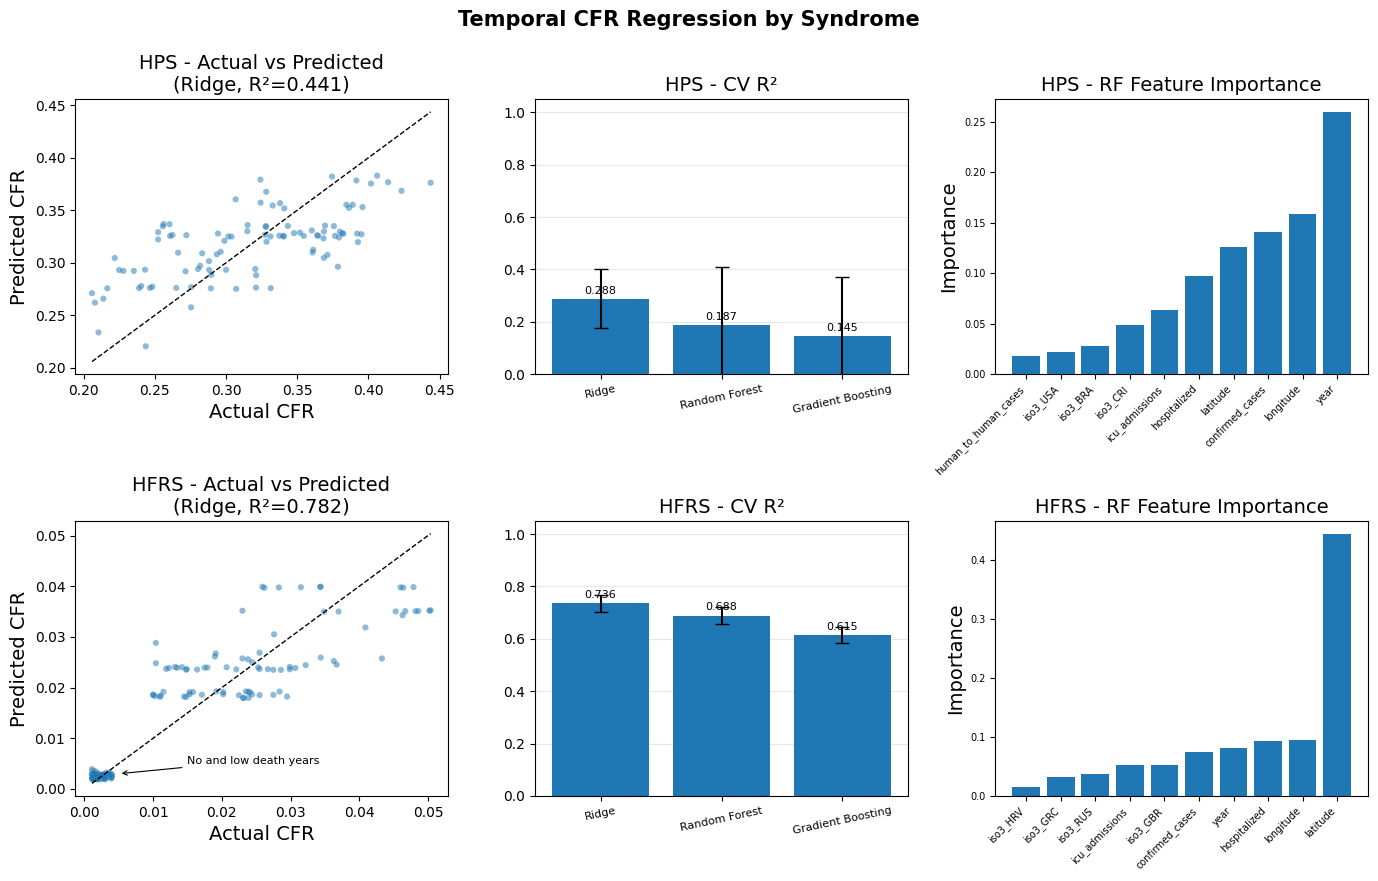

In [895]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle("Temporal CFR Regression by Syndrome", fontsize=15, fontweight="bold")

for row, syndrome in enumerate(["HPS", "HFRS"]):
    results = results_d[syndrome]
    fitted  = fitted_d[syndrome]
    ns      = list(results.keys())

    
    # Plot 1: Actual vs Predicted (for best model)
    best = max(results, key=lambda n: results[n]["test_r2"])
    _, y_pred, y_test = fitted[best]
    axes[row, 0].scatter(y_test, y_pred, alpha=0.5, edgecolors="none", s=20)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    axes[row, 0].plot(lims, lims, "k--", lw=1)
    axes[row, 0].set(title=f"{syndrome} - Actual vs Predicted\n({best}, R²={results[best]['test_r2']:.3f})",
                     xlabel="Actual CFR", ylabel="Predicted CFR")
    axes[row,0].set_axisbelow(True)

    if syndrome != "HPS":
        zero_mask = y_test == 0
        axes[row, 0].annotate(
            f"No and low death years",
            xy=(0.005, 0.003),
            xytext=(0.015, 0.005),
            fontsize=8,
            arrowprops=dict(arrowstyle="->", lw=0.8),
        )

    # Plot 2: CV R² bar chart
    axes[row, 1].bar(ns, [results[n]["cv_r2"] for n in ns],
                     yerr=[results[n]["cv_std"] for n in ns],
                     capsize=5)
    axes[row, 1].set_ylim(0, 1.05)
    axes[row, 1].set_title(f"{syndrome} - CV R²")
    axes[row, 1].set_xticklabels(ns, rotation=12, ha="center", fontsize=8)
    axes[row, 1].grid(axis="y", alpha=0.3)
    for i, n in enumerate(ns):
        axes[row, 1].text(i, results[n]["cv_r2"] + 0.02,
                          f"{results[n]['cv_r2']:.3f}", ha="center", fontsize=8)
    axes[row, 1].set_axisbelow(True)

    # Plot 3: Feature importance (Random Forest)
    rf_pipe = fitted["Random Forest"][0]
    feat_names = [f.split("__", 1)[-1]
                  for f in rf_pipe.named_steps["pre"].get_feature_names_out()]
    importances = rf_pipe.named_steps["reg"].feature_importances_
    imp_df = (pd.DataFrame({"feature": feat_names, "importance": importances})
              .sort_values("importance", ascending=False).head(10))
    axes[row, 2].bar(imp_df["feature"][::-1], imp_df["importance"][::-1])
    axes[row, 2].set_title(f"{syndrome} - RF Feature Importance")
    axes[row, 2].set_ylabel("Importance")
    axes[row, 2].tick_params(labelsize=7)
    axes[row, 2].set_xticks(axes[row, 2].get_xticks(),
                             axes[row, 2].get_xticklabels(), rotation=45, ha="right")
    axes[row, 2].set_axisbelow(True)

plt.tight_layout()